# Zastosowanie uczenia maszynowego do wykrywania anomalii w logach auditd systemu Linux

**Autorzy:** Lukasz Kierzek, Tomasz Gondek

**Cel:** porownanie prostej detekcji regulowej z metodami ML do wykrywania anomalii w logach auditd.

Porownywane metody:
- Rule-based detection,
- Isolation Forest,
- Local Outlier Factor.

Notebook jest przygotowany jako prezentacja wynikow: od danych, przez reguly i cechy, po porownanie metryk.

## 1. Przygotowanie srodowiska

Importujemy funkcje z projektu. Dane sa parsowane jako **zgrupowane zdarzenia auditd**, a nie pojedyncze linie logu. To wazne, bo jedno zdarzenie auditd moze skladac sie z kilku wpisow: `SYSCALL`, `EXECVE`, `PATH`, `CWD`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from config import LABELS_PATH, RAW_LOG_PATH
from src.audit_parser import parse_lines_grouped
from src.features import records_to_features
from src.labels import labels_to_series, load_labels
from src.log_loader import load_logs
from src.ml_detector import (
    predict_anomalies,
    predict_local_outlier_factor,
    train_isolation_forest,
    train_local_outlier_factor,
)
from src.preprocessing import (
    calculate_detection_statistics,
    calculate_labeled_metrics,
    compare_detection_methods,
    detections_to_dataframe,
    get_rule_anomaly_indices,
)
from src.rules import run_all_rules_with_context

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [2]:
logs = load_logs(RAW_LOG_PATH)
records = parse_lines_grouped(logs)
labels_df = load_labels(LABELS_PATH)
y_true = labels_to_series(labels_df, len(records))

print(f"Plik logow: {RAW_LOG_PATH}")
print(f"Liczba linii logu: {len([line for line in logs if line.strip()])}")
print(f"Liczba zgrupowanych zdarzen auditd: {len(records)}")
print(f"Liczba etykiet: {len(labels_df)}")

Plik logow: C:\Users\Kierzu\Documents\Cyberbezpieczeństwo sem II\Bezpieczeństwo i hardening systemów operacyjnych\projekt\data\raw\auditd_sample.log
Liczba linii logu: 36
Liczba zgrupowanych zdarzen auditd: 28
Liczba etykiet: 28


## 2. Dane i etykiety

Etykieta `1` oznacza zdarzenie anomalne/podejrzane, a `0` oznacza zdarzenie normalne. Etykiety sa przygotowane w `data/labels.csv` i sluza do policzenia metryk jak precision, recall oraz F1.

In [3]:
labels_overview = labels_df.copy()
labels_overview["class"] = labels_overview["label"].map({0: "normal", 1: "anomaly"})
labels_overview.head(10)

,record_index,audit_id,label,scenario,class
0,0,101,1,privilege_escalation_shadow_read,anomaly
1,1,102,0,normal_ssh_authentication,normal
2,2,103,0,normal_ssh_accounting,normal
3,3,104,0,normal_log_read,normal
4,4,105,0,normal_directory_listing,normal
5,5,106,1,access_denied_avc,anomaly
6,6,107,1,firewall_configuration_change,anomaly
7,7,108,0,normal_shell_execution,normal
8,8,109,0,normal_python_command,normal
9,9,110,0,normal_python_execution,normal


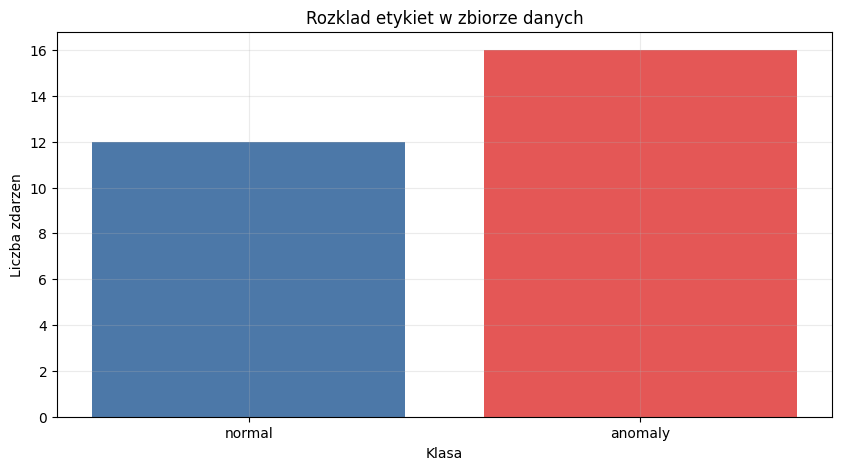

,count
class,
normal,12
anomaly,16


In [4]:
label_counts = labels_overview["class"].value_counts().reindex(["normal", "anomaly"], fill_value=0)

plt.bar(label_counts.index, label_counts.values, color=["#4c78a8", "#e45756"])
plt.title("Rozklad etykiet w zbiorze danych")
plt.xlabel("Klasa")
plt.ylabel("Liczba zdarzen")
plt.show()

label_counts.to_frame("count")

## 3. Przykladowe zgrupowane zdarzenia

Tabela ponizej pokazuje, co parser wyciaga z logow: identyfikator auditd, typ zdarzenia, uzytkownika, komende, sciezke i etykiete.

In [5]:
events_df = pd.DataFrame([
    {
        "record_index": index,
        "audit_id": record.audit_id,
        "timestamp": record.timestamp,
        "event_type": record.event_type,
        "uid": record.user_id,
        "auid": record.audit_user_id,
        "command": record.command,
        "executable": record.executable,
        "path": record.path,
        "success": record.success,
        "label": int(y_true.iloc[index]),
    }
    for index, record in enumerate(records)
])

events_df.head(12)

,record_index,audit_id,timestamp,event_type,uid,auid,command,executable,path,success,label
0,0,101,2024-05-14 09:20:01.001,"SYSCALL,EXECVE,CWD,PATH,PATH",1000,1000,sudo,/usr/bin/sudo,/usr/bin/cat,True,1
1,1,102,2024-05-14 09:20:02.112,USER_AUTH,0,4294967295,NaN,/usr/sbin/sshd,NaN,True,0
2,2,103,2024-05-14 09:20:02.113,USER_ACCT,0,4294967295,NaN,/usr/sbin/sshd,NaN,True,0
3,3,104,2024-05-14 09:20:03.221,"SYSCALL,PATH",1000,1000,cat,/usr/bin/cat,/var/log/auth.log,True,0
4,4,105,2024-05-14 09:20:04.331,USER_CMD,1000,1000,ls,NaN,NaN,True,0
5,5,106,2024-05-14 09:20:05.441,AVC,NaN,NaN,nginx,NaN,error.log,None,1
6,6,107,2024-05-14 09:20:06.551,NETFILTER_CFG,NaN,NaN,iptables,NaN,NaN,True,1
7,7,108,2024-05-14 09:20:07.661,"SYSCALL,EXECVE",1000,1000,bash,/usr/bin/bash,NaN,True,0
8,8,109,2024-05-14 09:20:08.771,"CWD,USER_CMD",1000,1000,python3,NaN,NaN,True,0
9,9,110,2024-05-14 09:20:09.881,"SYSCALL,EXECVE",1000,1000,python3,/usr/bin/python3,NaN,True,0


## 4. Detekcja regulowa

Reguly sa czytelne i latwe do wyjasnienia. W projekcie wykrywaja m.in. podejrzane komendy, aktywnosc roota, nieudane operacje, nietypowe godziny, nietypowe UID, narzedzia administracyjne i podejrzane sciezki.

In [6]:
detections_by_record = run_all_rules_with_context(records)
stats = calculate_detection_statistics(records)
detections_df = detections_to_dataframe(records)

summary_df = pd.DataFrame([
    {"metric": "total_events", "value": stats["total_logs"]},
    {"metric": "rule_anomalies", "value": stats["anomaly_logs"]},
    {"metric": "rule_normal", "value": stats["normal_logs"]},
    {
        "metric": "rule_anomaly_percentage",
        "value": round(stats["anomaly_logs"] / stats["total_logs"] * 100, 2) if stats["total_logs"] else 0,
    },
])
summary_df

,metric,value
0,total_events,28.00
1,rule_anomalies,22.00
2,rule_normal,6.00
3,rule_anomaly_percentage,78.57


In [7]:
rule_summary = (
    detections_df["rule"]
    .value_counts()
    .rename_axis("rule")
    .reset_index(name="detections")
)
rule_summary

,rule,detections
0,Night Activity,13
1,Root Activity,8
2,Unknown Command,7
3,Suspicious Command,6
4,Administrative Tool,5
5,Failed Command,5
6,Unusual UID,3
7,Unusual Event Combination,3
8,Suspicious Executable Path,1


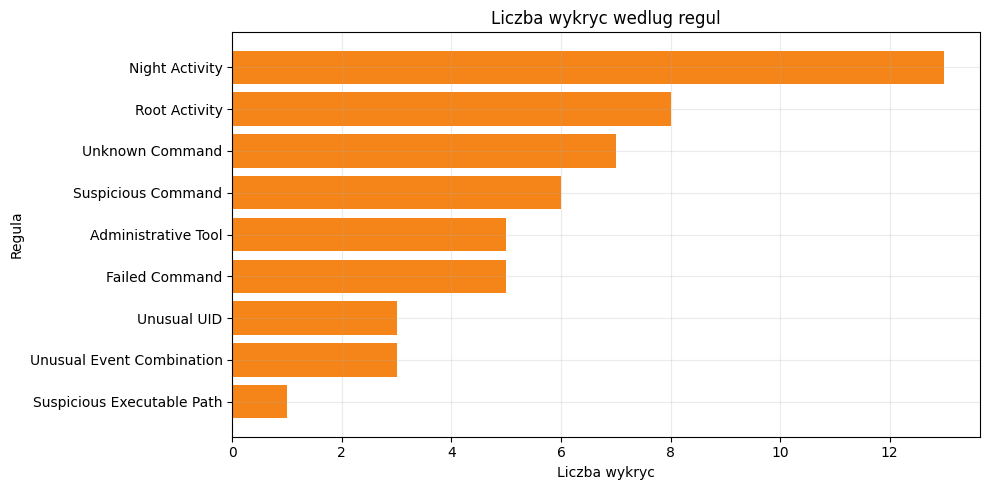

In [8]:
if not rule_summary.empty:
    plt.barh(rule_summary["rule"], rule_summary["detections"], color="#f58518")
    plt.title("Liczba wykryc wedlug regul")
    plt.xlabel("Liczba wykryc")
    plt.ylabel("Regula")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [9]:
detections_df.head(15)

,timestamp,command,user_id,rule,reason
0,2024-05-14 09:20:01.001,sudo,1000,Administrative Tool,Administrative tool executed: sudo
1,2024-05-14 09:20:02.112,NaN,0,Root Activity,Root user activity detected
2,2024-05-14 09:20:02.112,NaN,0,Unusual UID,"Unusual uid/auid combination: uid=0, auid=4294..."
3,2024-05-14 09:20:02.113,NaN,0,Root Activity,Root user activity detected
4,2024-05-14 09:20:02.113,NaN,0,Unusual UID,"Unusual uid/auid combination: uid=0, auid=4294..."
5,2024-05-14 09:20:05.441,nginx,NaN,Unknown Command,Unknown command detected: nginx
6,2024-05-14 09:20:06.551,iptables,NaN,Administrative Tool,Administrative tool executed: iptables
7,2024-05-14 09:20:10.991,NaN,1000,Suspicious Executable Path,Suspicious path used: /home/lukasz/projects/sc...
8,2024-05-14 09:20:12.101,NaN,0,Root Activity,Root user activity detected
9,2024-05-14 09:20:12.101,NaN,0,Failed Command,Command execution failed


## 5. Feature engineering

Modele ML dostaja cechy liczbowe opisujace zdarzenie. Przyklady: godzina, aktywnosc roota, sukces operacji, nietypowa sciezka, komenda administracyjna, roznica `uid`/`auid` oraz dlugosc komunikatu logu.

In [10]:
features_df = records_to_features(records)
features_df.head()

,hour,is_root,success,is_night,is_suspicious_command,is_admin_tool,is_unknown_command,has_executable,has_path,has_suspicious_path,uid,auid,uid_mismatch,event_type_code,command_length,raw_message_length
0,9,0,1,0,0,1,0,1,1,1,1000,1000,0,87,4,664
1,9,1,1,0,0,0,1,1,0,0,0,4294967295,1,20,0,219
2,9,1,1,0,0,0,1,1,0,0,0,4294967295,1,97,0,215
3,9,0,1,0,0,0,0,1,1,0,1000,1000,0,84,3,367
4,9,0,1,0,0,0,0,0,0,1,1000,1000,0,26,2,147


In [11]:
feature_summary = features_df.describe().T[["mean", "std", "min", "max"]].round(2)
feature_summary

,mean,std,min,max
hour,5.290000e+00,4.060000e+00,1.0,9.000000e+00
is_root,2.900000e-01,4.600000e-01,0.0,1.000000e+00
success,7.500000e-01,4.400000e-01,0.0,1.000000e+00
is_night,4.600000e-01,5.100000e-01,0.0,1.000000e+00
is_suspicious_command,2.100000e-01,4.200000e-01,0.0,1.000000e+00
is_admin_tool,1.800000e-01,3.900000e-01,0.0,1.000000e+00
is_unknown_command,1.400000e-01,3.600000e-01,0.0,1.000000e+00
has_executable,8.200000e-01,3.900000e-01,0.0,1.000000e+00
has_path,1.400000e-01,3.600000e-01,0.0,1.000000e+00
has_suspicious_path,1.400000e-01,3.600000e-01,0.0,1.000000e+00


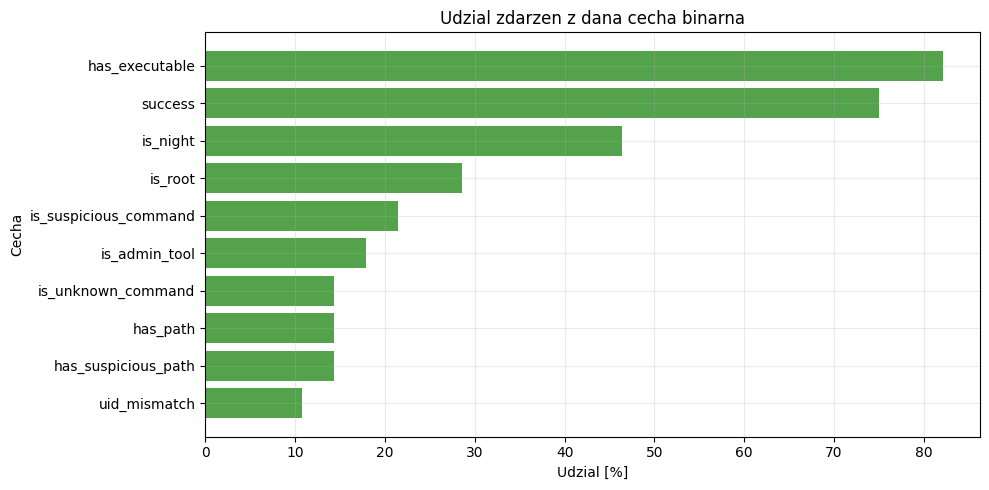

In [12]:
binary_features = [
    "is_root",
    "success",
    "is_night",
    "is_suspicious_command",
    "is_admin_tool",
    "is_unknown_command",
    "has_executable",
    "has_path",
    "has_suspicious_path",
    "uid_mismatch",
]

binary_rates = features_df[binary_features].mean().sort_values(ascending=False) * 100

plt.barh(binary_rates.index, binary_rates.values, color="#54a24b")
plt.title("Udzial zdarzen z dana cecha binarna")
plt.xlabel("Udzial [%]")
plt.ylabel("Cecha")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Modele ML

Uzyte modele sa nienadzorowane, czyli nie wymagaja etykiet podczas treningu. Etykiety wykorzystujemy dopiero do oceny wynikow.

**Isolation Forest** izoluje nietypowe punkty w losowych drzewach.

**Local Outlier Factor** sprawdza, czy punkt ma znacznie mniejsza gestosc sasiedztwa niz podobne punkty.

In [13]:
isolation_model = train_isolation_forest(features_df)
isolation_predictions = predict_anomalies(isolation_model, features_df)

lof_model = train_local_outlier_factor(features_df)
lof_predictions = predict_local_outlier_factor(lof_model, features_df)

rule_indices = get_rule_anomaly_indices(records)
isolation_indices = {index for index, value in enumerate(isolation_predictions) if value == -1}
lof_indices = {index for index, value in enumerate(lof_predictions) if value == -1}

print(f"Rule-based anomalies: {len(rule_indices)}")
print(f"Isolation Forest anomalies: {len(isolation_indices)}")
print(f"Local Outlier Factor anomalies: {len(lof_indices)}")

Rule-based anomalies: 22
Isolation Forest anomalies: 2
Local Outlier Factor anomalies: 1


## 7. Porownanie liczby wykrytych anomalii

Ten wykres pokazuje, ile zdarzen kazda metoda oznaczyla jako anomalie. Sama liczba wykryc nie oznacza jeszcze skutecznosci, dlatego w kolejnej sekcji liczymy metryki na etykietach.

In [14]:
comparison_df = compare_detection_methods(records, isolation_predictions, lof_predictions)
comparison_df

,method,detected_anomalies,percentage,overlap_with_rules
0,Rule-based,22,78.57,22
1,Isolation Forest,2,7.14,2
2,Local Outlier Factor,1,3.57,1


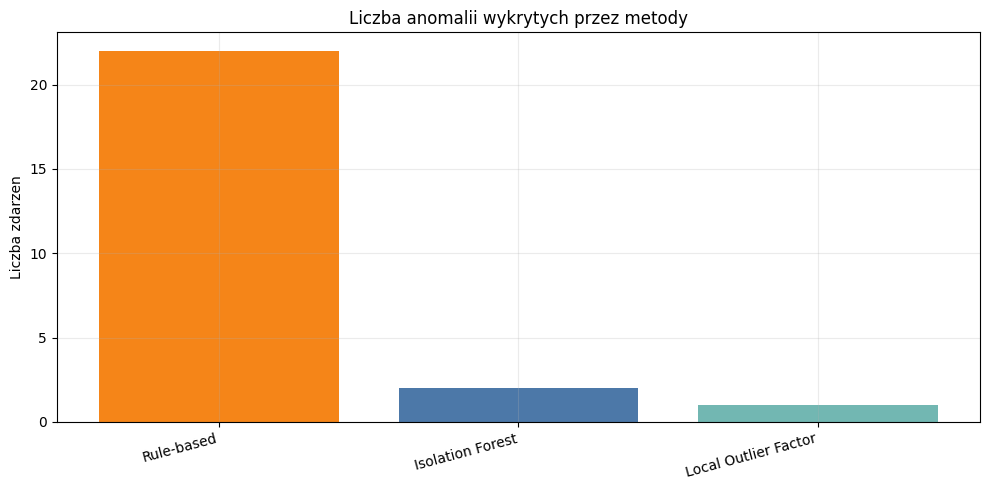

In [15]:
plt.bar(comparison_df["method"], comparison_df["detected_anomalies"], color=["#f58518", "#4c78a8", "#72b7b2"])
plt.title("Liczba anomalii wykrytych przez metody")
plt.ylabel("Liczba zdarzen")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 8. Ocena na danych oznaczonych

Dzieki `data/labels.csv` mozemy policzyc:
- **accuracy**: ogolna trafnosc,
- **precision**: ile wykryc bylo faktycznie anomaliami,
- **recall**: ile faktycznych anomalii wykryto,
- **F1**: kompromis miedzy precision i recall.

In [16]:
labeled_metrics_df = calculate_labeled_metrics(
    records,
    y_true,
    isolation_predictions,
    lof_predictions,
)
labeled_metrics_df

,method,tp,fp,tn,fn,accuracy,precision,recall,f1
0,Rule-based,16,6,6,0,78.57,72.73,100.00,84.21
1,Isolation Forest,1,1,11,15,42.86,50.00,6.25,11.11
2,Local Outlier Factor,0,1,11,16,39.29,0.00,0.00,0.00


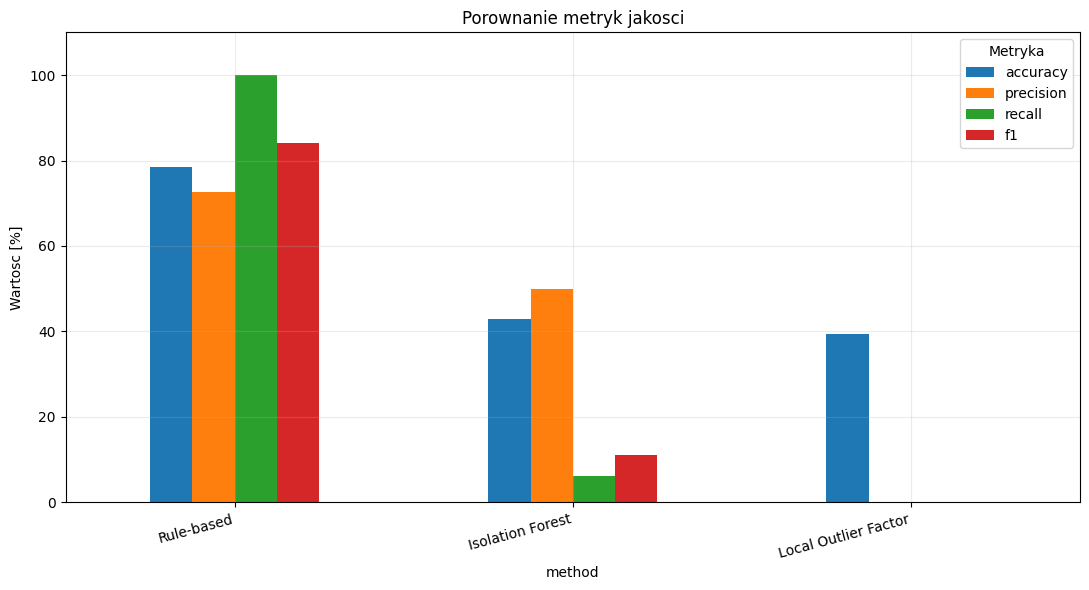

In [17]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1"]
plot_df = labeled_metrics_df.set_index("method")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Porownanie metryk jakosci")
plt.ylabel("Wartosc [%]")
plt.ylim(0, 110)
plt.xticks(rotation=15, ha="right")
plt.legend(title="Metryka")
plt.tight_layout()
plt.show()

In [18]:
best_f1 = labeled_metrics_df.sort_values("f1", ascending=False).iloc[0]
best_recall = labeled_metrics_df.sort_values("recall", ascending=False).iloc[0]
best_precision = labeled_metrics_df.sort_values("precision", ascending=False).iloc[0]

pd.DataFrame([
    {"criterion": "best_f1", "method": best_f1["method"], "value": best_f1["f1"]},
    {"criterion": "best_recall", "method": best_recall["method"], "value": best_recall["recall"]},
    {"criterion": "best_precision", "method": best_precision["method"], "value": best_precision["precision"]},
])

,criterion,method,value
0,best_f1,Rule-based,84.21
1,best_recall,Rule-based,100.00
2,best_precision,Rule-based,72.73


## 9. Macierze pomylek

Macierz pomylek pokazuje konkretne bledy:
- `TP`: poprawnie wykryte anomalie,
- `FP`: normalne zdarzenia oznaczone jako anomalie,
- `TN`: poprawnie wykryte normalne zdarzenia,
- `FN`: anomalie przeoczone przez metode.

In [19]:
confusion_long = labeled_metrics_df[["method", "tp", "fp", "tn", "fn"]].melt(
    id_vars="method",
    var_name="type",
    value_name="count",
)

pivot_confusion = confusion_long.pivot(index="method", columns="type", values="count")[["tp", "fp", "tn", "fn"]]
pivot_confusion

type,tp,fp,tn,fn
method,,,,
Isolation Forest,1,1,11,15
Local Outlier Factor,0,1,11,16
Rule-based,16,6,6,0


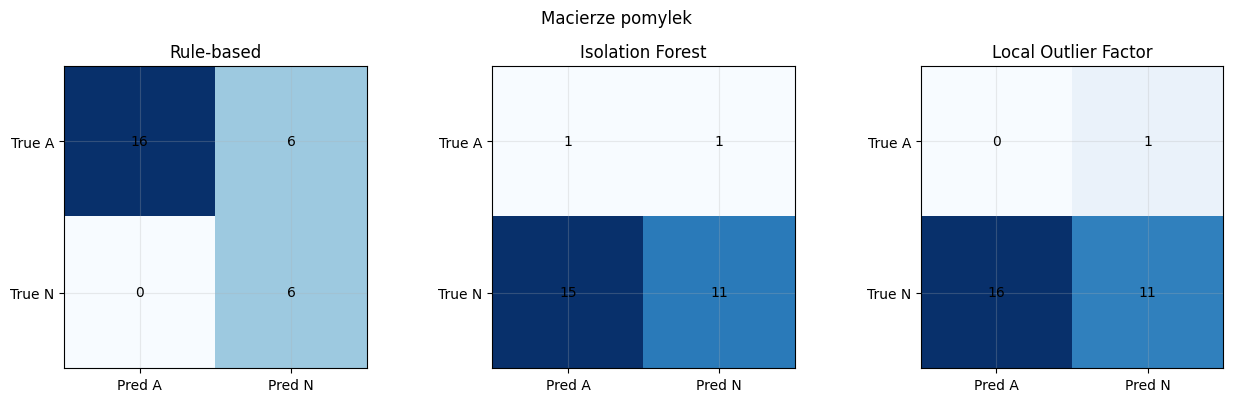

In [20]:
fig, axes = plt.subplots(1, len(labeled_metrics_df), figsize=(13, 4))

for ax, row in zip(axes, labeled_metrics_df.itertuples(index=False)):
    matrix = [[row.tp, row.fp], [row.fn, row.tn]]
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_title(row.method)
    ax.set_xticks([0, 1], labels=["Pred A", "Pred N"])
    ax.set_yticks([0, 1], labels=["True A", "True N"])

    for y in range(2):
        for x in range(2):
            ax.text(x, y, matrix[y][x], ha="center", va="center", color="black")

fig.suptitle("Macierze pomylek")
plt.tight_layout()
plt.show()

## 10. Czesc wspolna wykryc

Porownujemy, ktore zdarzenia zostaly wykryte tylko przez jedna metode, a ktore przez wszystkie. To pomaga pokazac, ze reguly i ML moga wskazywac inne typy nietypowych zachowan.

In [21]:
overlap_df = pd.DataFrame([
    {"category": "Rule only", "count": len(rule_indices - isolation_indices - lof_indices)},
    {"category": "Isolation only", "count": len(isolation_indices - rule_indices - lof_indices)},
    {"category": "LOF only", "count": len(lof_indices - rule_indices - isolation_indices)},
    {"category": "Rule + Isolation", "count": len((rule_indices & isolation_indices) - lof_indices)},
    {"category": "Rule + LOF", "count": len((rule_indices & lof_indices) - isolation_indices)},
    {"category": "Isolation + LOF", "count": len((isolation_indices & lof_indices) - rule_indices)},
    {"category": "All methods", "count": len(rule_indices & isolation_indices & lof_indices)},
])
overlap_df

,category,count
0,Rule only,19
1,Isolation only,0
2,LOF only,0
3,Rule + Isolation,2
4,Rule + LOF,1
5,Isolation + LOF,0
6,All methods,0


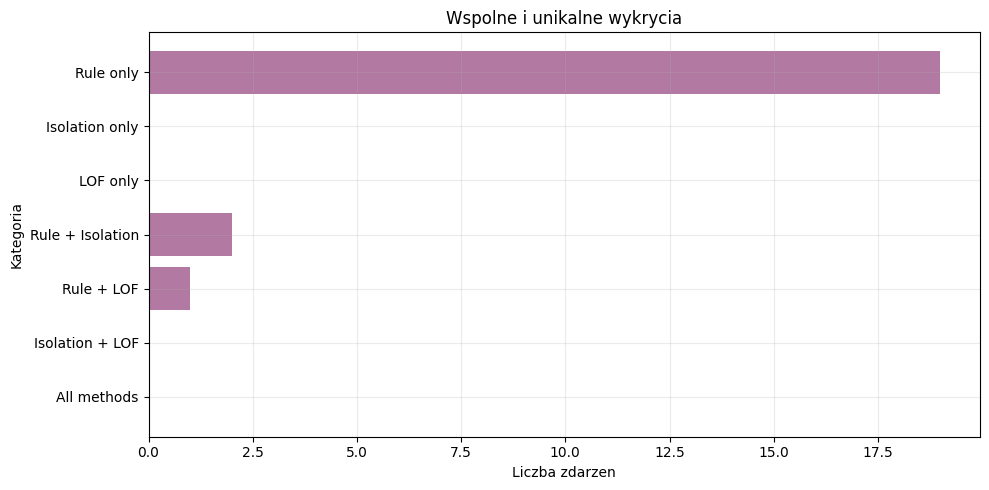

In [22]:
plt.barh(overlap_df["category"], overlap_df["count"], color="#b279a2")
plt.title("Wspolne i unikalne wykrycia")
plt.xlabel("Liczba zdarzen")
plt.ylabel("Kategoria")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Szczegoly wykryc metod

Tabela laczy etykiety, dane zdarzenia i decyzje kazdej metody. To najbardziej praktyczny widok do omawiania konkretnych przypadkow.

In [23]:
method_decisions_df = events_df.copy()
method_decisions_df["label_name"] = method_decisions_df["label"].map({0: "normal", 1: "anomaly"})
method_decisions_df["rule_based"] = [index in rule_indices for index in range(len(records))]
method_decisions_df["isolation_forest"] = [index in isolation_indices for index in range(len(records))]
method_decisions_df["local_outlier_factor"] = [index in lof_indices for index in range(len(records))]
method_decisions_df["scenario"] = labels_df.set_index("record_index").reindex(range(len(records)))["scenario"].values

method_decisions_df[[
    "record_index",
    "audit_id",
    "scenario",
    "label_name",
    "command",
    "uid",
    "auid",
    "success",
    "rule_based",
    "isolation_forest",
    "local_outlier_factor",
]].head(20)

,record_index,audit_id,scenario,label_name,command,uid,auid,success,rule_based,isolation_forest,local_outlier_factor
0,0,101,privilege_escalation_shadow_read,anomaly,sudo,1000,1000,True,True,False,False
1,1,102,normal_ssh_authentication,normal,NaN,0,4294967295,True,True,False,False
2,2,103,normal_ssh_accounting,normal,NaN,0,4294967295,True,True,False,True
3,3,104,normal_log_read,normal,cat,1000,1000,True,False,False,False
4,4,105,normal_directory_listing,normal,ls,1000,1000,True,False,False,False
5,5,106,access_denied_avc,anomaly,nginx,NaN,NaN,None,True,False,False
6,6,107,firewall_configuration_change,anomaly,iptables,NaN,NaN,True,True,False,False
7,7,108,normal_shell_execution,normal,bash,1000,1000,True,False,False,False
8,8,109,normal_python_command,normal,python3,1000,1000,True,False,False,False
9,9,110,normal_python_execution,normal,python3,1000,1000,True,False,False,False


In [24]:
missed_anomalies = method_decisions_df[
    (method_decisions_df["label"] == 1)
    & ~method_decisions_df["rule_based"]
    & ~method_decisions_df["isolation_forest"]
    & ~method_decisions_df["local_outlier_factor"]
]

missed_anomalies[["record_index", "scenario", "command", "uid", "success"]]

,record_index,scenario,command,uid,success


## 12. Automatyczne podsumowanie wynikow

In [25]:
print("Podsumowanie projektu")
print(f"Liczba zgrupowanych zdarzen auditd: {len(records)}")
print(f"Liczba anomalii wedlug etykiet: {int(y_true.sum())}")
print(f"Liczba zdarzen normalnych wedlug etykiet: {len(y_true) - int(y_true.sum())}")
print()

for row in labeled_metrics_df.itertuples(index=False):
    print(
        f"{row.method}: F1={row.f1}%, "
        f"precision={row.precision}%, recall={row.recall}%, "
        f"TP={row.tp}, FP={row.fp}, TN={row.tn}, FN={row.fn}"
    )

print()
print(f"Najlepsza metoda wedlug F1: {best_f1['method']} ({best_f1['f1']}%)")
print("Interpretacja: reguly dobrze wykrywaja znane scenariusze, a ML jest dodatkiem do wskazywania nietypowych zdarzen liczbowych.")
print("Ograniczenie: zbior danych jest maly, dlatego wyniki ML sa demonstracyjne i wymagaja wiekszej liczby logow normalnych oraz atakowych.")

Podsumowanie projektu
Liczba zgrupowanych zdarzen auditd: 28
Liczba anomalii wedlug etykiet: 16
Liczba zdarzen normalnych wedlug etykiet: 12

Rule-based: F1=84.21%, precision=72.73%, recall=100.0%, TP=16, FP=6, TN=6, FN=0
Isolation Forest: F1=11.11%, precision=50.0%, recall=6.25%, TP=1, FP=1, TN=11, FN=15
Local Outlier Factor: F1=0.0%, precision=0.0%, recall=0.0%, TP=0, FP=1, TN=11, FN=16

Najlepsza metoda wedlug F1: Rule-based (84.21%)
Interpretacja: reguly dobrze wykrywaja znane scenariusze, a ML jest dodatkiem do wskazywania nietypowych zdarzen liczbowych.
Ograniczenie: zbior danych jest maly, dlatego wyniki ML sa demonstracyjne i wymagaja wiekszej liczby logow normalnych oraz atakowych.


## 13. Wnioski koncowe

- Detekcja regulowa jest najlepsza dla znanych i latwych do opisania scenariuszy, np. `hydra`, `nmap`, aktywnosc roota, nieudane operacje.
- Isolation Forest i Local Outlier Factor dzialaja bez etykiet, ale potrzebuja wiekszego zbioru danych, aby sensownie odroznic zachowania normalne od nietypowych.
- Najbardziej wartosciowe dalsze rozszerzenie projektu to zebranie wiekszej liczby logow i dopisanie etykiet dla scenariuszy: normalna praca, brute force, rekonesans, eskalacja uprawnien, modyfikacja konfiguracji.
- W obecnym stanie projekt dobrze pokazuje roznice miedzy podejsciem regulowym i ML oraz ograniczenia uczenia maszynowego na malym zbiorze danych.